In [25]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

import re
import joblib
import random
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import matplotlib as mpl
from syd import make_viewer, Viewer
from tqdm import tqdm
import optuna

from vrAnalysis.database import get_database
from vrAnalysis.helpers import Timer, get_placefield_location, uniq_val_filter
from vrAnalysis.processors.em import process_session
from vrAnalysis.processors.placefields import get_placefield, get_placefield_prediction, convert_position_to_bins
from vrAnalysis.processors.support import get_gauss_kernel, convolve_toeplitz, smooth
from dimensionality_manuscript.registry import PopulationRegistry
from dimensionality_manuscript import LocPredConfig
from dimensionality_manuscript import ResultsStore, ResultsAggregator
from dimensionality_manuscript.configs.locprediction import _partition_kept_rois



plt.rcParams["font.size"] = 18

# get session database
sessiondb = get_database("vrSessions")

# get population registry and models
registry = PopulationRegistry()
cfg = LocPredConfig(norm_method="zero-one", norm_scale=1.0, fit_iterations=5)

In [26]:
cfg = LocPredConfig()
sessions = sessiondb.iter_sessions(imaging=True)
store = ResultsStore()
results = ResultsAggregator(cfg, store, sessions)

In [30]:
for k, v in results.arrays.items():
    print(k, v.shape)

print("\n")
for k, v in results.objects.items():
    print(k, type(v))

idx_keep_rois (149, 2, 20014)
true_position_bins_te (149, 2, 1137)


loss_trajectory <class 'numpy.ndarray'>
loss_scalar <class 'numpy.ndarray'>
true_bin_score <class 'numpy.ndarray'>
idx_keep_rois_half_a <class 'numpy.ndarray'>
iteration_position_bins_tr <class 'numpy.ndarray'>
idx_keep_rois_half_b <class 'numpy.ndarray'>
likelihood_matrix <class 'numpy.ndarray'>


C:\Users\Andrew\AppData\Local\Temp\ipykernel_31732\1457886240.py:22: RuntimeWarning: Mean of empty slice
  sum_loss_scalars[k][im] = np.nanmean(loss_scalars[k][idx_mouse], axis=0)


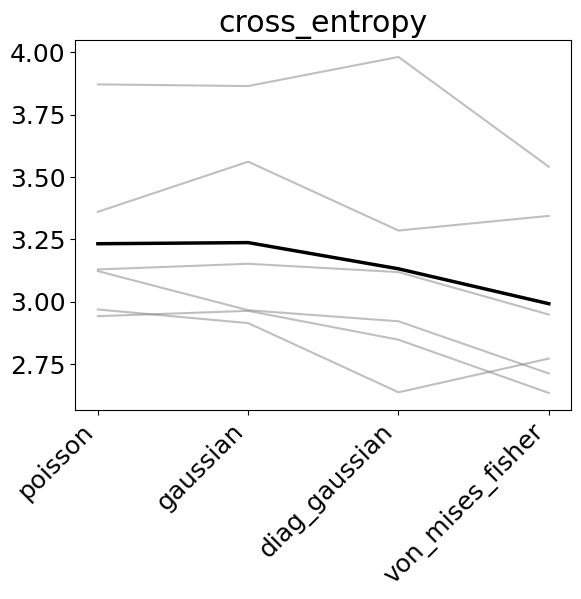

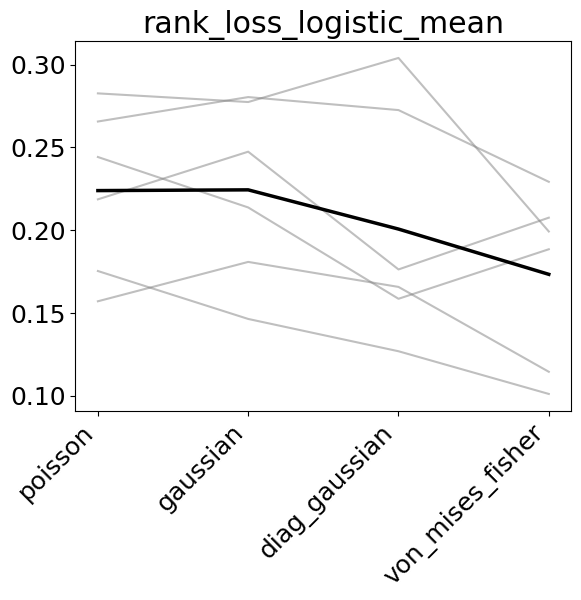

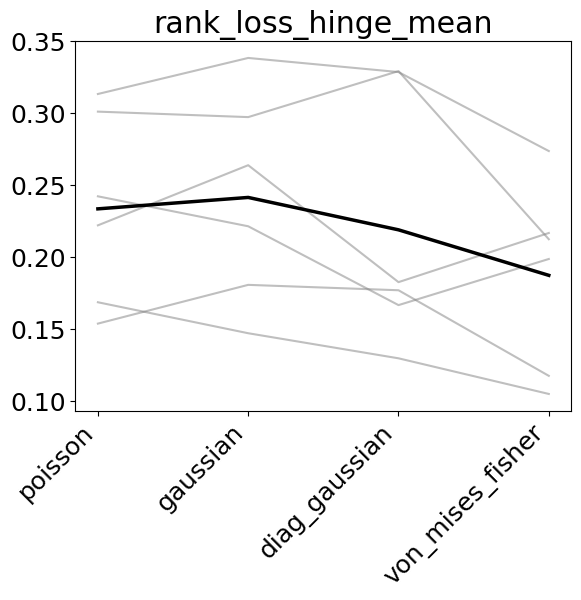

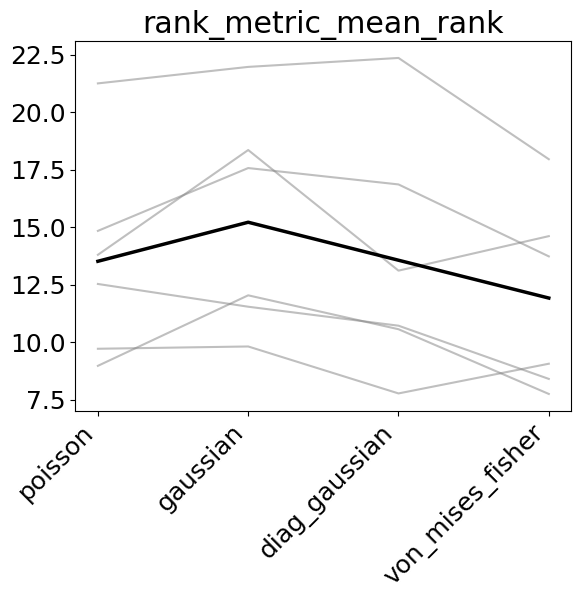

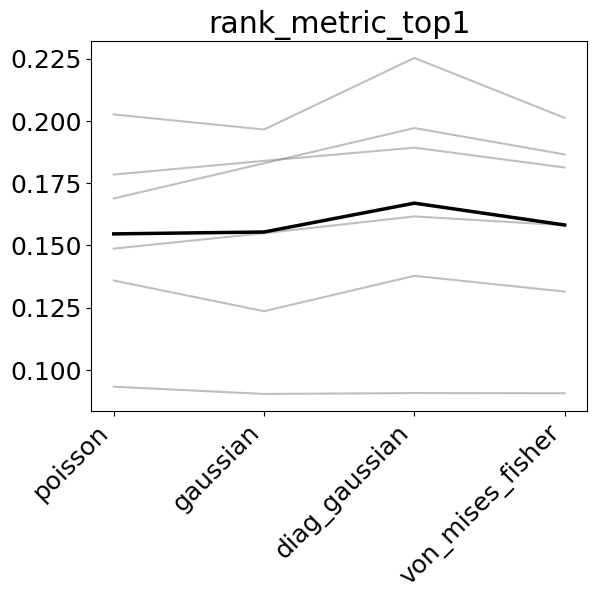

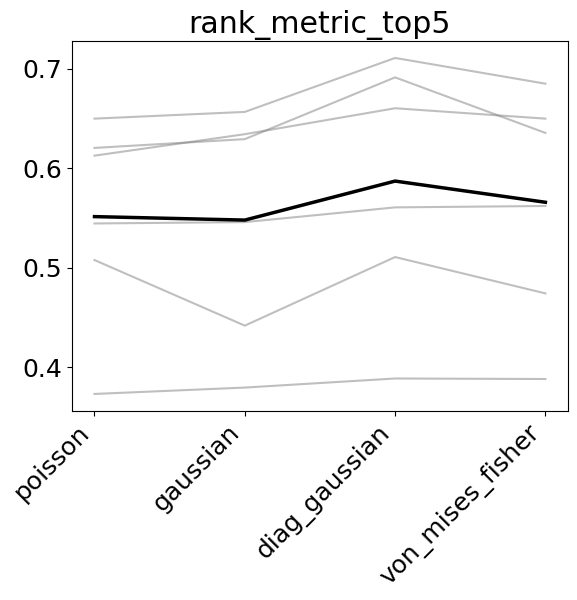

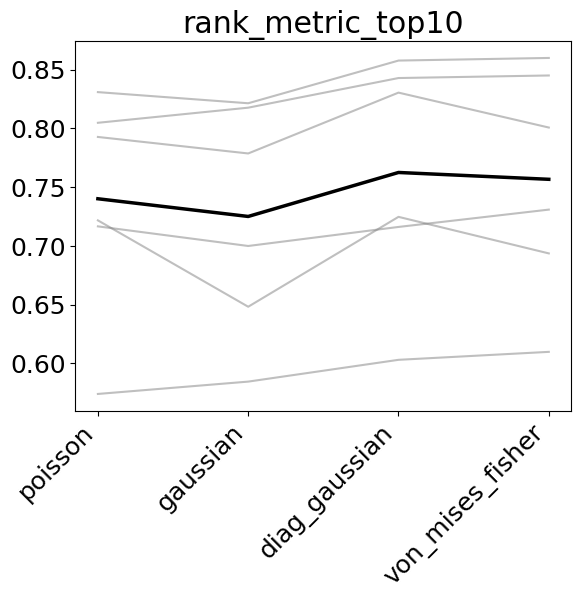

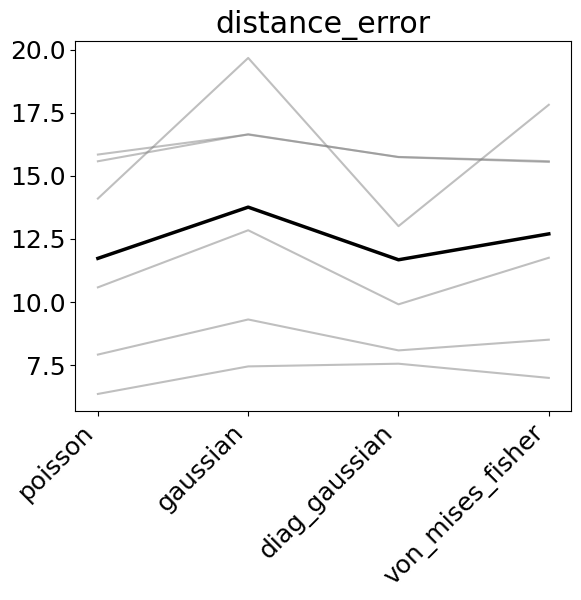

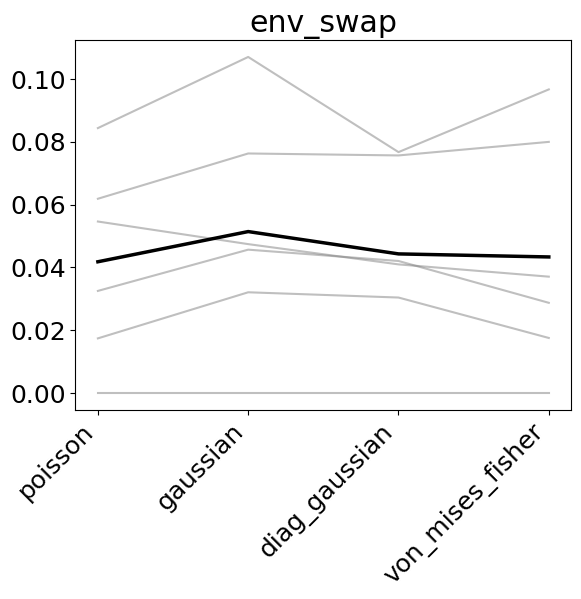

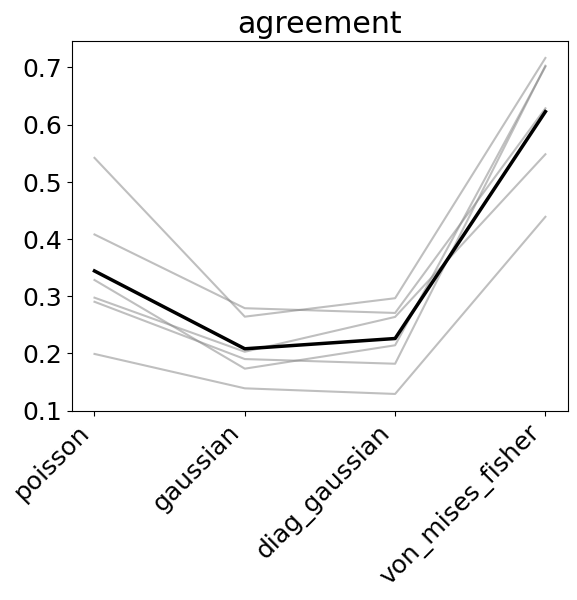

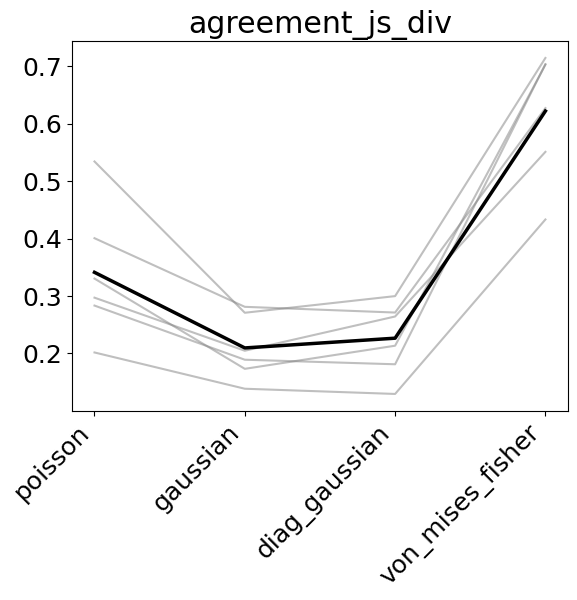

In [42]:
# keys = list(results.objects["loss_scalar"].keys())
from collections import defaultdict

shape = results.objects["loss_scalar"].shape
keys = results.objects["loss_scalar"][0, 0].keys()
loss_scalars = defaultdict(lambda: np.full(shape, np.nan))
for ises in range(shape[0]):
    for it in range(shape[1]):
        for k in keys:
            if results.objects["loss_scalar"][(ises, it)] is not None:
                loss_scalars[k][ises, it] = results.objects["loss_scalar"][(ises, it)][k][0]

loss_types = [re.fullmatch(r"poisson_(.+)", k).group(1) for k in loss_scalars if re.fullmatch(r"poisson_(.+)", k)]
likelihood_methods = cfg.likelihood_methods
mouse_names = np.unique(results.mouse_names)
num_mice = len(mouse_names)

sum_loss_scalars = defaultdict(lambda: np.full((num_mice, shape[1]), np.nan))
for k in loss_scalars:
    for im, mouse in enumerate(mouse_names):
        idx_mouse = results.mouse_names == mouse
        sum_loss_scalars[k][im] = np.nanmean(loss_scalars[k][idx_mouse], axis=0)

show_big_ass_plots = True
if show_big_ass_plots:
    ii = 0
    for loss in loss_types:
        # gather likelihood methods for that loss
        c_keys = [lmethod + "_" + loss for lmethod in likelihood_methods]
        num_keys = len(c_keys)
        c_data = np.full((num_keys, num_mice, shape[1]), np.nan)
        for ik, k in enumerate(c_keys):
            c_data[ik] = sum_loss_scalars[k]

        c_data = c_data #/ c_data[0]

        plt.close("all")
        plt.plot(c_data[:, :, ii], color="gray", alpha=0.5)
        plt.plot(np.nanmean(c_data[:, :, ii], axis=1).T, color="black", alpha=1.0, linewidth=2.5)
        plt.title(loss)
        plt.xticks(range(num_keys), likelihood_methods, rotation=45, ha="right")
        plt.show()

In [15]:
isession = 41
spks_type = "oasis"


session_iterable = sessiondb.iter_sessions(imaging=True, session_params=dict(spks_type=spks_type))



# session = random.choice([s for s in session_iterable if s.mouse_name == "ATL027"])
session = session_iterable[isession]
print(session)



print(session.environments)

cfg = LocPredConfig(norm_method="zero-one", norm_scale=1.0, fit_iterations=5)
fit = cfg.fit(session, registry)
mask_a, mask_b = _partition_kept_rois(fit.idx_keep_rois, cfg.agreement_split_seed)
fit_a = cfg.fit(session, registry, idx_rois=mask_a)
fit_b = cfg.fit(session, registry, idx_rois=mask_b)

hyperparameters = cfg.optimize(session, registry, fit)


score_null = cfg.score(session, registry, fit, hyperparameters=None, iteration=0, fit_a=fit_a, fit_b=fit_b)
score = cfg.score(session, registry, fit, hyperparameters=hyperparameters, iteration=0, fit_a=fit_a, fit_b=fit_b)



# Full process with iterations and stuff
results = cfg.process(session, registry)

B2Session(mouse_name='ATL022', date='2023-04-18', session_id='701', spks_type='oasis')
[1 3]


In [16]:
loss_types = [re.fullmatch(r"poisson_(.+)", k).group(1) for k in score["loss_scalar"].keys() if re.fullmatch(r"poisson_(.+)", k)]
print("Loss types:")
for loss_type in loss_types:
    print(f"  {loss_type}")

print("Likelihood methods:")
print(cfg.likelihood_methods)

print("Results:")
print("\n   ".join(list(results.keys())))

Loss types:
  cross_entropy
  rank_loss_logistic_mean
  rank_loss_hinge_mean
  rank_metric_mean_rank
  rank_metric_top1
  rank_metric_top5
  rank_metric_top10
  distance_error
  env_swap
  agreement
  agreement_js_div
Likelihood methods:
('poisson', 'gaussian', 'diag_gaussian', 'von_mises_fisher')
Results:
likelihood_matrix
   loss_trajectory
   loss_scalar
   true_bin_score
   true_position_bins_te
   idx_keep_rois
   iteration_position_bins_tr
   idx_keep_rois_half_a
   idx_keep_rois_half_b


In [17]:
# For looking how the test scores change across iterations of fit (in EM routine)
method_width = max(len(method) for method in cfg.likelihood_methods)

for loss_type in loss_types:
    print(f"Loss type: {loss_type}")
    for method in cfg.likelihood_methods:
        _scores = np.array(results["loss_scalar"][f"{method}_{loss_type}"])
        _scores = _scores / np.min(_scores)
        _scores = np.array([np.round(s, 3) for s in _scores])
        print(f"  {method.ljust(method_width)}: {_scores}")

Loss type: cross_entropy
  poisson         : [1.    1.134 1.238 1.395 1.577]
  gaussian        : [1.    1.155 1.286 1.413 1.574]
  diag_gaussian   : [1.    1.231 1.631 2.243 3.368]
  von_mises_fisher: [1.    1.224 1.375 1.488 1.589]
Loss type: rank_loss_logistic_mean
  poisson         : [1.    2.251 3.068 4.954 7.182]
  gaussian        : [1.    1.704 2.387 3.196 4.33 ]
  diag_gaussian   : [ 1.     2.226  4.189 10.782 31.047]
  von_mises_fisher: [1.    2.001 2.832 3.478 3.963]
Loss type: rank_loss_hinge_mean
  poisson         : [1.    2.131 3.092 5.142 8.181]
  gaussian        : [1.    1.722 2.476 3.381 4.75 ]
  diag_gaussian   : [ 1.     2.636  5.04  12.386 33.658]
  von_mises_fisher: [1.    1.957 2.906 3.632 4.206]
Loss type: rank_metric_mean_rank
  poisson         : [1.    1.793 2.807 4.55  6.465]
  gaussian        : [1.    1.695 2.429 3.277 4.506]
  diag_gaussian   : [1.    1.871 2.926 4.553 6.76 ]
  von_mises_fisher: [1.    1.732 2.432 2.989 3.451]
Loss type: rank_metric_top1
  poi

In [7]:
# For comparing without validation to with validation
method_width = max(len(method) for method in cfg.likelihood_methods)

for loss_type in loss_types:
    print(loss_type)

    for likelihood_method in cfg.likelihood_methods:
        _score_null = score_null["loss_scalar"][f"{likelihood_method}_{loss_type}"]
        _score = score["loss_scalar"][f"{likelihood_method}_{loss_type}"]

        print(f"   {likelihood_method:<{method_width}} : " f"{_score_null:8.2f} -> {_score:8.2f}")

cross_entropy
   poisson          :    13.99 ->     3.77
   gaussian         :     2.93 ->     3.66
   diag_gaussian    :   100.03 ->     2.48
   von_mises_fisher :     5.07 ->     3.32
rank_loss_logistic_mean
   poisson          :     0.39 ->     0.25
   gaussian         :     0.11 ->     0.26
   diag_gaussian    :     2.62 ->     0.06
   von_mises_fisher :     0.58 ->     0.15
rank_loss_hinge_mean
   poisson          :     0.41 ->     0.15
   gaussian         :     0.09 ->     0.20
   diag_gaussian    :     2.64 ->     0.06
   von_mises_fisher :     0.76 ->     0.11
rank_metric_mean_rank
   poisson          :     5.49 ->     5.49
   gaussian         :     8.08 ->     8.08
   diag_gaussian    :     5.73 ->     5.73
   von_mises_fisher :     6.33 ->     6.33
rank_metric_top1
   poisson          :     0.19 ->     0.19
   gaussian         :     0.17 ->     0.17
   diag_gaussian    :     0.20 ->     0.20
   von_mises_fisher :     0.18 ->     0.18
rank_metric_top5
   poisson          :    

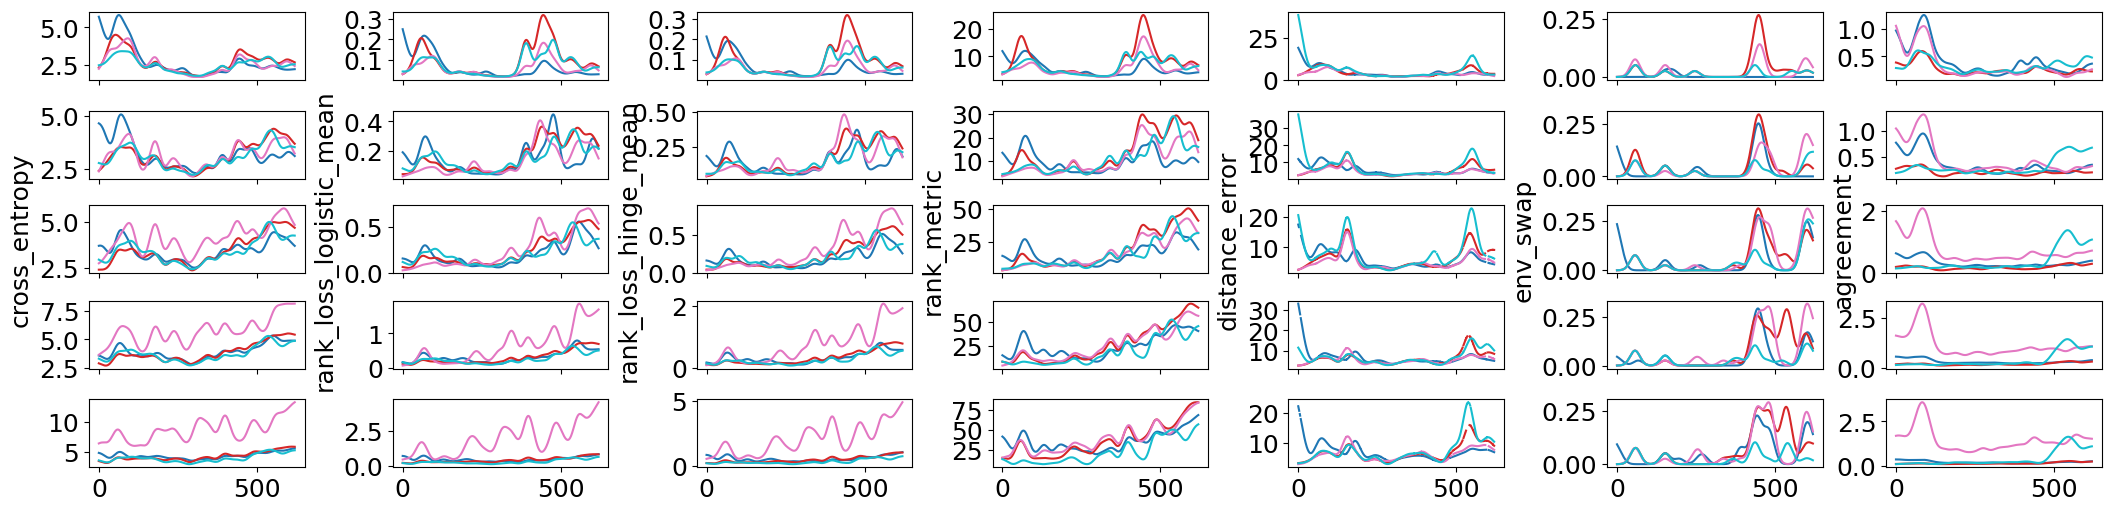

In [8]:
from scipy.stats import zscore

# Get m
num_loss = len(cfg.loss_methods)
num_ll = len(cfg.likelihood_methods)
colors = plt.colormaps["tab10"](np.linspace(0, 1, num_ll))

num_iterations = cfg.fit_iterations
norm = lambda x: x  # zscore(x, axis=-1, nan_policy="omit")

plt.close("all")
fig, ax = plt.subplots(num_iterations, num_loss, figsize=(3 * num_loss, 5), layout="constrained", sharex=True)
for iloss, loss_method in enumerate(cfg.loss_methods):
    for ill, ll_method in enumerate(cfg.likelihood_methods):
        ckey = f"{ll_method}_{loss_method}"
        cval = results["loss_trajectory"][ckey]
        xx = np.arange(cval.shape[-1])
        fval = smooth(cval, xx, 11)
        for iteration in range(num_iterations):
            ax[iteration, iloss].plot(norm(fval[iteration]), color=colors[ill], label=ll_method)
    ax[2, iloss].set_ylabel(loss_method)
    # ax[iloss].legend()

plt.show()

In [8]:
for k, val in results["true_bin_score"].items():
    print(f"{k}: {val.shape}")

poisson: (5, 621)
gaussian: (5, 621)
diag_gaussian: (5, 621)
von_mises_fisher: (5, 621)


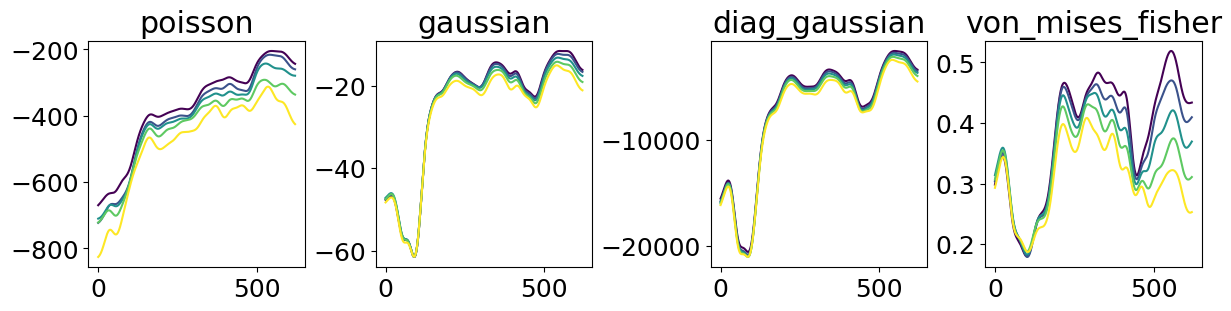

In [18]:
# Get m
num_ll = len(cfg.likelihood_methods)
num_iterations = cfg.fit_iterations
colors = plt.colormaps["viridis"](np.linspace(0, 1, num_iterations))

norm = lambda x: x  # zscore(x, axis=-1, nan_policy="omit")

plt.close("all")
fig, ax = plt.subplots(1, num_ll, figsize=(3 * num_ll, 3), layout="constrained", sharex=True)
for ill, ll_method in enumerate(cfg.likelihood_methods):
    cval = results["true_bin_score"][ll_method]
    xx = np.arange(cval.shape[-1])
    fval = smooth(cval, xx, 11)
    for iteration in range(num_iterations):
        ax[ill].plot(norm(fval[iteration]), color=colors[iteration], label=ll_method)
    ax[ill].set_title(ll_method)

plt.show()

In [19]:
# ROI selection summary + final-iteration scalar table
n_total = fit.idx_keep_rois.shape[0]
n_kept = int(fit.idx_keep_rois.sum())
print(f"ROIs: {n_kept}/{n_total} kept ({100*n_kept/n_total:.1f}%)")
print()

key_metrics = {
    "cross_entropy": "xent",
    "distance_error": "dist_err",
    "env_swap": "env_swap",
    "rank_metric_top5": "top5",
    "rank_metric_mean_rank": "mean_rank",
    "agreement": "agreement",
}
col_w = 12
header = f"{'likelihood':<22}" + "".join(f"{label:>{col_w}}" for label in key_metrics.values())
print(header)
print("-" * len(header))
for ll in cfg.likelihood_methods:
    row = f"{ll:<22}"
    for metric_key in key_metrics:
        key = f"{ll}_{metric_key}"
        vals = results["loss_scalar"].get(key)
        row += f"{vals[-1]:>{col_w}.4f}" if vals is not None else f"{'N/A':>{col_w}}"
    print(row)

ROIs: 7604/18020 kept (42.2%)

likelihood                    xent    dist_err    env_swap        top5   mean_rank   agreement
----------------------------------------------------------------------------------------------
poisson                     4.3893      7.2653      0.0531      0.3961     35.4783      0.2398
gaussian                    4.2746      6.4913      0.0757      0.3994     36.4074      0.1525
diag_gaussian               8.6252      5.9349      0.0596      0.4300     38.8068      1.4144
von_mises_fisher            3.9674      7.3575      0.0225      0.4428     21.8470      0.4131


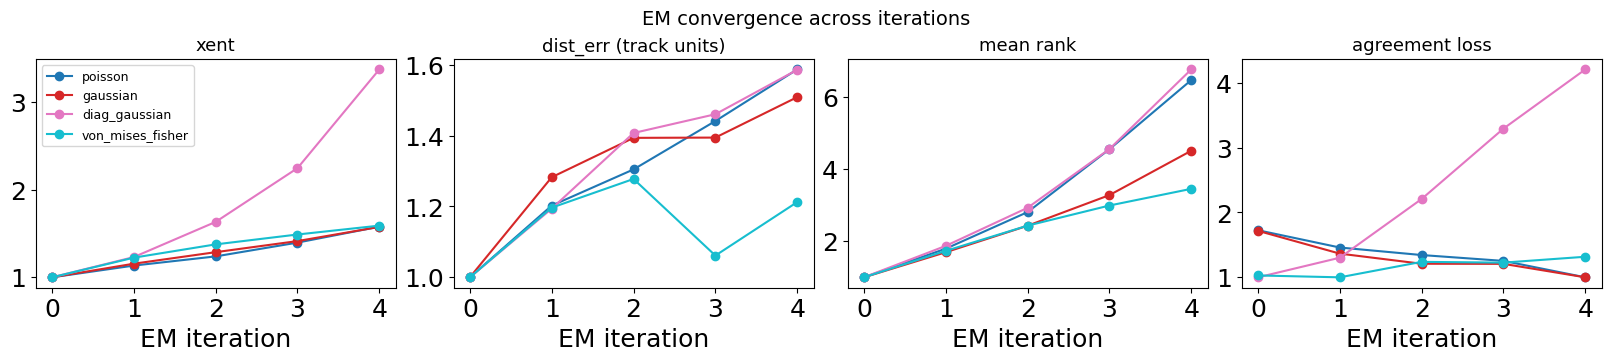

In [24]:
# EM convergence: key scalars vs. iteration
key_metrics = {
    "cross_entropy": "xent",
    "distance_error": "dist_err (track units)",
    "rank_metric_mean_rank": "mean rank",
    "agreement": "agreement loss",
}
colors = plt.colormaps["tab10"](np.linspace(0, 1, len(cfg.likelihood_methods)))
iterations = np.arange(cfg.fit_iterations)

fig, axes = plt.subplots(1, len(key_metrics), figsize=(4 * len(key_metrics), 3.5), layout="constrained")
for ax, (metric_key, metric_label) in zip(axes, key_metrics.items()):
    for ill, ll in enumerate(cfg.likelihood_methods):
        vals = results["loss_scalar"].get(f"{ll}_{metric_key}")
        if vals is not None:
            ax.plot(iterations, vals / np.min(vals), marker="o", color=colors[ill], label=ll)
    ax.set_title(metric_label, fontsize=13)
    ax.set_xlabel("EM iteration")
    ax.set_xticks(iterations)

axes[0].legend(fontsize=9)
plt.suptitle("EM convergence across iterations", fontsize=14)
plt.show()

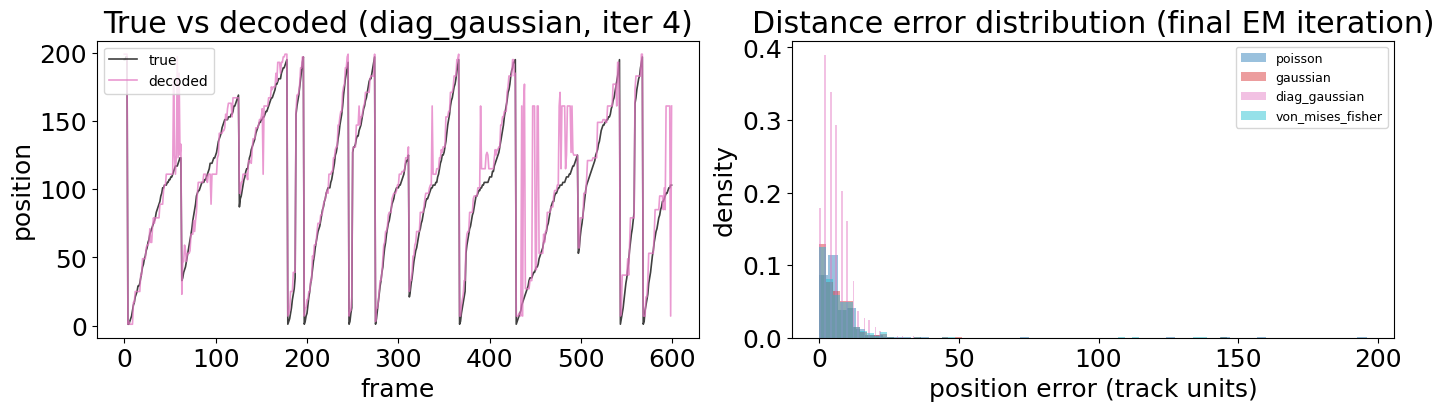

In [14]:
# Decoded vs true position (final iteration, diag_gaussian) + distance error distributions
ll_key = "diag_gaussian"
num_bins = cfg.num_bins
bin_centers = (fit.dist_edges[:-1] + fit.dist_edges[1:]) / 2.0
true_bins = results["true_position_bins_te"]
true_pos = bin_centers[true_bins % num_bins]

ll_matrix = results["likelihood_matrix"][ll_key][-1]  # (frames, total_bins)
pred_bins = np.argmax(ll_matrix, axis=1)
pred_pos = bin_centers[pred_bins % num_bins]

colors = plt.colormaps["tab10"](np.linspace(0, 1, len(cfg.likelihood_methods)))

fig, axes = plt.subplots(1, 2, figsize=(14, 4), layout="constrained")

# Left: time-series of decoded vs true position
window = 600
axes[0].plot(true_pos[:window], label="true", alpha=0.75, lw=1.2, color="k")
axes[0].plot(pred_pos[:window], label="decoded", alpha=0.75, lw=1.2, color=colors[2])
axes[0].set_xlabel("frame")
axes[0].set_ylabel("position")
axes[0].set_title(f"True vs decoded ({ll_key}, iter {cfg.fit_iterations - 1})")
axes[0].legend(fontsize=10)

# Right: distance error distribution per likelihood method (final iteration, env-matched frames only)
for ill, ll in enumerate(cfg.likelihood_methods):
    traj = results["loss_trajectory"][f"{ll}_distance_error"][-1]
    valid = traj[~np.isnan(traj)]
    axes[1].hist(valid, bins=60, alpha=0.45, color=colors[ill], label=ll, density=True)
axes[1].set_xlabel("position error (track units)")
axes[1].set_ylabel("density")
axes[1].set_title("Distance error distribution (final EM iteration)")
axes[1].legend(fontsize=9)

plt.show()

In [14]:
from dimensionality_manuscript import LocPredCrossVal

cfg_cv = LocPredCrossVal(norm_method="zero-one", norm_scale=10.0)

fit_cv = cfg_cv.fit(session, registry)
result_cv = cfg_cv.score(session, registry, fit_cv)

n_source = int(fit_cv.idx_keep_source.sum())
n_target = int(fit_cv.idx_keep_target.sum())
n_total_source = fit_cv.idx_keep_source.shape[0]
n_total_target = fit_cv.idx_keep_target.shape[0]
print(f"Source ROIs : {n_source}/{n_total_source} kept ({100*n_source/n_total_source:.1f}%)")
print(f"Target ROIs : {n_target}/{n_total_target} kept ({100*n_target/n_total_target:.1f}%)")
print(f"Test frames : {result_cv['true_bins_te'].shape[0]}")
print()

# Summary table
col_w = 14
header = f"{'likelihood':<22}{'oracle_r2':>{col_w}}" + "     internal"
print(header)
print("-" * len(header))
for ll in cfg_cv.likelihood_methods:
    internal = result_cv["internal_r2"][ll]
    oracle = result_cv["oracle_r2"]
    pct = 100 * internal / oracle if oracle != 0 else float("nan")
    row = f"{ll:<22}{oracle:>{col_w}.4f}{internal:>{col_w}.4f}"
    print(row)

print()
print(f"{'oracle R²':<22}: {result_cv['oracle_r2']:.4f}")
for ll in cfg_cv.likelihood_methods:
    internal = result_cv["internal_r2"][ll]
    oracle = result_cv["oracle_r2"]
    pct = 100 * internal / oracle if oracle != 0 else float("nan")
    print(f"  internal ({ll:<18}): {internal:.4f}  ({pct:.1f}% of oracle)")

Source ROIs : 1691/4172 kept (40.5%)
Target ROIs : 1705/4172 kept (40.9%)
Test frames : 621

likelihood                 oracle_r2     internal
-------------------------------------------------
poisson                       0.0920        0.0916
gaussian                      0.0920        0.0933
diag_gaussian                 0.0920        0.0937
von_mises_fisher              0.0920        0.0932

oracle R²             : 0.0920
  internal (poisson           ): 0.0916  (99.5% of oracle)
  internal (gaussian          ): 0.0933  (101.4% of oracle)
  internal (diag_gaussian     ): 0.0937  (101.8% of oracle)
  internal (von_mises_fisher  ): 0.0932  (101.3% of oracle)


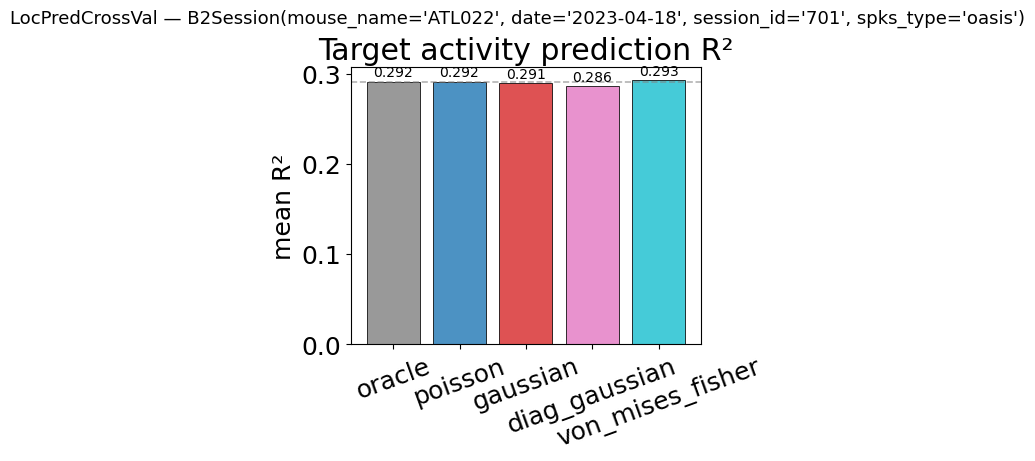

In [13]:
# Oracle vs internal R²: bar chart + per-ROI distributions
colors_cv = plt.colormaps["tab10"](np.linspace(0, 1, len(cfg_cv.likelihood_methods)))
oracle_r2 = result_cv["oracle_r2"]

fig, ax = plt.subplots(1, 1, figsize=(5, 4.5), layout="constrained")

# Left: mean R² bars — oracle vs each likelihood
bar_labels = ["oracle"] + list(cfg_cv.likelihood_methods)
bar_values = [oracle_r2] + [result_cv["internal_r2"][ll] for ll in cfg_cv.likelihood_methods]
bar_colors = ["gray"] + list(colors_cv)
bars = ax.bar(bar_labels, bar_values, color=bar_colors, alpha=0.8, edgecolor="k", linewidth=0.7)
ax.axhline(oracle_r2, color="gray", lw=1.2, ls="--", alpha=0.6)
ax.set_ylabel("mean R²")
ax.set_title("Target activity prediction R²")
ax.tick_params(axis="x", rotation=20)
for bar, val in zip(bars, bar_values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.002, f"{val:.3f}", ha="center", va="bottom", fontsize=10)

plt.suptitle(f"LocPredCrossVal — {session}", fontsize=13)
plt.show()